# CALB_old clean-cells rxn-lim sweep + routing rule

Tests whether pure reaction-limited SEI is sufficient for the typical CALB_old
cell, or whether the joint SEI+LAM machinery from notebook 08 is needed cohort-wide.

Scope: 9 clean cells (≥1000 cy, residual std < 0.8 pp, no sensor zeros). All
calibrated against the whole-trajectory smoothed slope; long sims for the full
measured horizon; RMSE per cell + per window.

**Headline finding: 7 of 9 cells calibrate well with pure rxn-lim (RMSE < 2.2 pp).
2 cells fail badly (RMSE > 10 pp): cells 24 and 30, both with non-monotonic
shapes that single-mechanism SEI can't reproduce.**

Generated by `Voltaris/scripts/calb_clean_cells_rxnlim_sweep.py`.

In [1]:
from __future__ import annotations
import json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

REPO = Path("/home/hj/Desktop/PINNs").resolve()
OUT  = REPO / "Voltaris/outputs/tuned_params"
CSV  = OUT / "CALB_clean_rxnlim_sweep_summary.csv"
df = pd.read_csv(CSV)
print(f"Loaded sweep summary: {len(df)} cells")

Loaded sweep summary: 9 cells


## 1. Per-cell summary table

Sorted by full-trajectory RMSE (best fits first). The colour bar highlights
which cells the rxn-lim-only model handles well (low RMSE) vs which need more.


In [2]:
summary_cols = ["cell", "shape", "n_cycles",
                 "pre_age_to_soh", "soh_start_meas", "soh_end_meas",
                 "target_slope_pp_per_100cy", "achieved_slope_pp_per_100cy",
                 "j_SEI", "rmse_full_pp", "delta_end_pp"]
table = df[summary_cols].sort_values("rmse_full_pp").reset_index(drop=True)
display(table.style.format({
    "pre_age_to_soh": "{:.3f}",
    "soh_start_meas": "{:.2f}",
    "soh_end_meas":   "{:.2f}",
    "target_slope_pp_per_100cy":   "{:+.4f}",
    "achieved_slope_pp_per_100cy": "{:+.4f}",
    "j_SEI":     "{:.3e}",
    "rmse_full_pp": "{:.2f}",
    "delta_end_pp": "{:+.2f}",
}).background_gradient(subset=["rmse_full_pp"], cmap="RdYlGn_r"))

,cell,shape,n_cycles,pre_age_to_soh,soh_start_meas,soh_end_meas,target_slope_pp_per_100cy,achieved_slope_pp_per_100cy,j_SEI,rmse_full_pp,delta_end_pp
0,CALB_old_10,near-linear,1031,0.829,82.88,74.33,-0.8194,-0.9326,1.000e-07,0.26,-0.36
1,CALB_old_25,near-linear,1445,0.835,83.47,76.13,-0.5536,-0.5251,5.623e-08,0.32,+0.21
2,CALB_old_20,near-linear,1301,0.771,77.15,65.69,-0.9005,-0.7403,1.000e-07,1.36,+2.66
3,CALB_old_6,accelerating,1105,0.673,67.32,59.85,-0.5958,-0.5698,1.000e-07,1.39,+1.61
4,CALB_old_19,decelerating,1217,0.670,66.97,51.11,-1.1710,-1.3697,1.778e-07,1.43,+1.52
5,CALB_old_7,accelerating,1194,0.606,60.57,48.02,-0.8653,-0.8991,1.334e-07,1.71,+2.92
6,CALB_old_14,near-linear,1303,0.632,63.15,51.59,-0.7926,-0.7329,1.334e-07,2.19,+3.01
7,CALB_old_30,three-regime,1809,0.615,61.49,61.49,-0.3879,-0.3955,5.623e-08,10.89,-6.67
8,CALB_old_24,accelerating,1487,0.517,51.72,51.75,-0.8309,-0.6654,1.778e-07,11.82,-8.78


## 2. Full-trajectory RMSE by cell

Visualises the gap between "rxn-lim works" (≤ 2.2 pp) and "rxn-lim fails" (≥ 10 pp).
There's nothing in between — the cohort splits cleanly into two populations.

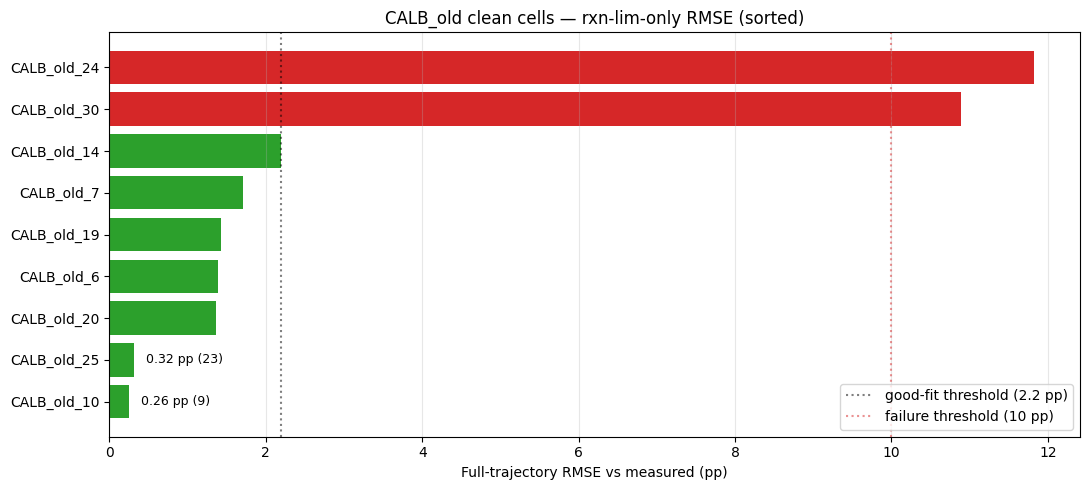

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
rows = df.sort_values("rmse_full_pp")
colors = ["#d62728" if r > 5 else "#2ca02c" for r in rows.rmse_full_pp]
ax.barh(rows.cell, rows.rmse_full_pp, color=colors)
for i, (r, s) in enumerate(zip(rows.rmse_full_pp, rows.shape)):
    ax.text(r + 0.15, i, f"{r:.2f} pp ({s})", va="center", fontsize=9)
ax.axvline(2.2, ls=":", color="black", alpha=0.5, label="good-fit threshold (2.2 pp)")
ax.axvline(10,  ls=":", color="#d62728", alpha=0.5, label="failure threshold (10 pp)")
ax.set_xlabel("Full-trajectory RMSE vs measured (pp)")
ax.set_title("CALB_old clean cells — rxn-lim-only RMSE (sorted)", fontsize=12)
ax.legend(loc="lower right")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

## 3. 3×3 grid — sim overlay per cell

Generated alongside the sweep. Green = pure rxn-lim sim, red = measured
(Hampel-filtered). Last row's cells 24 and 30 are the failures.

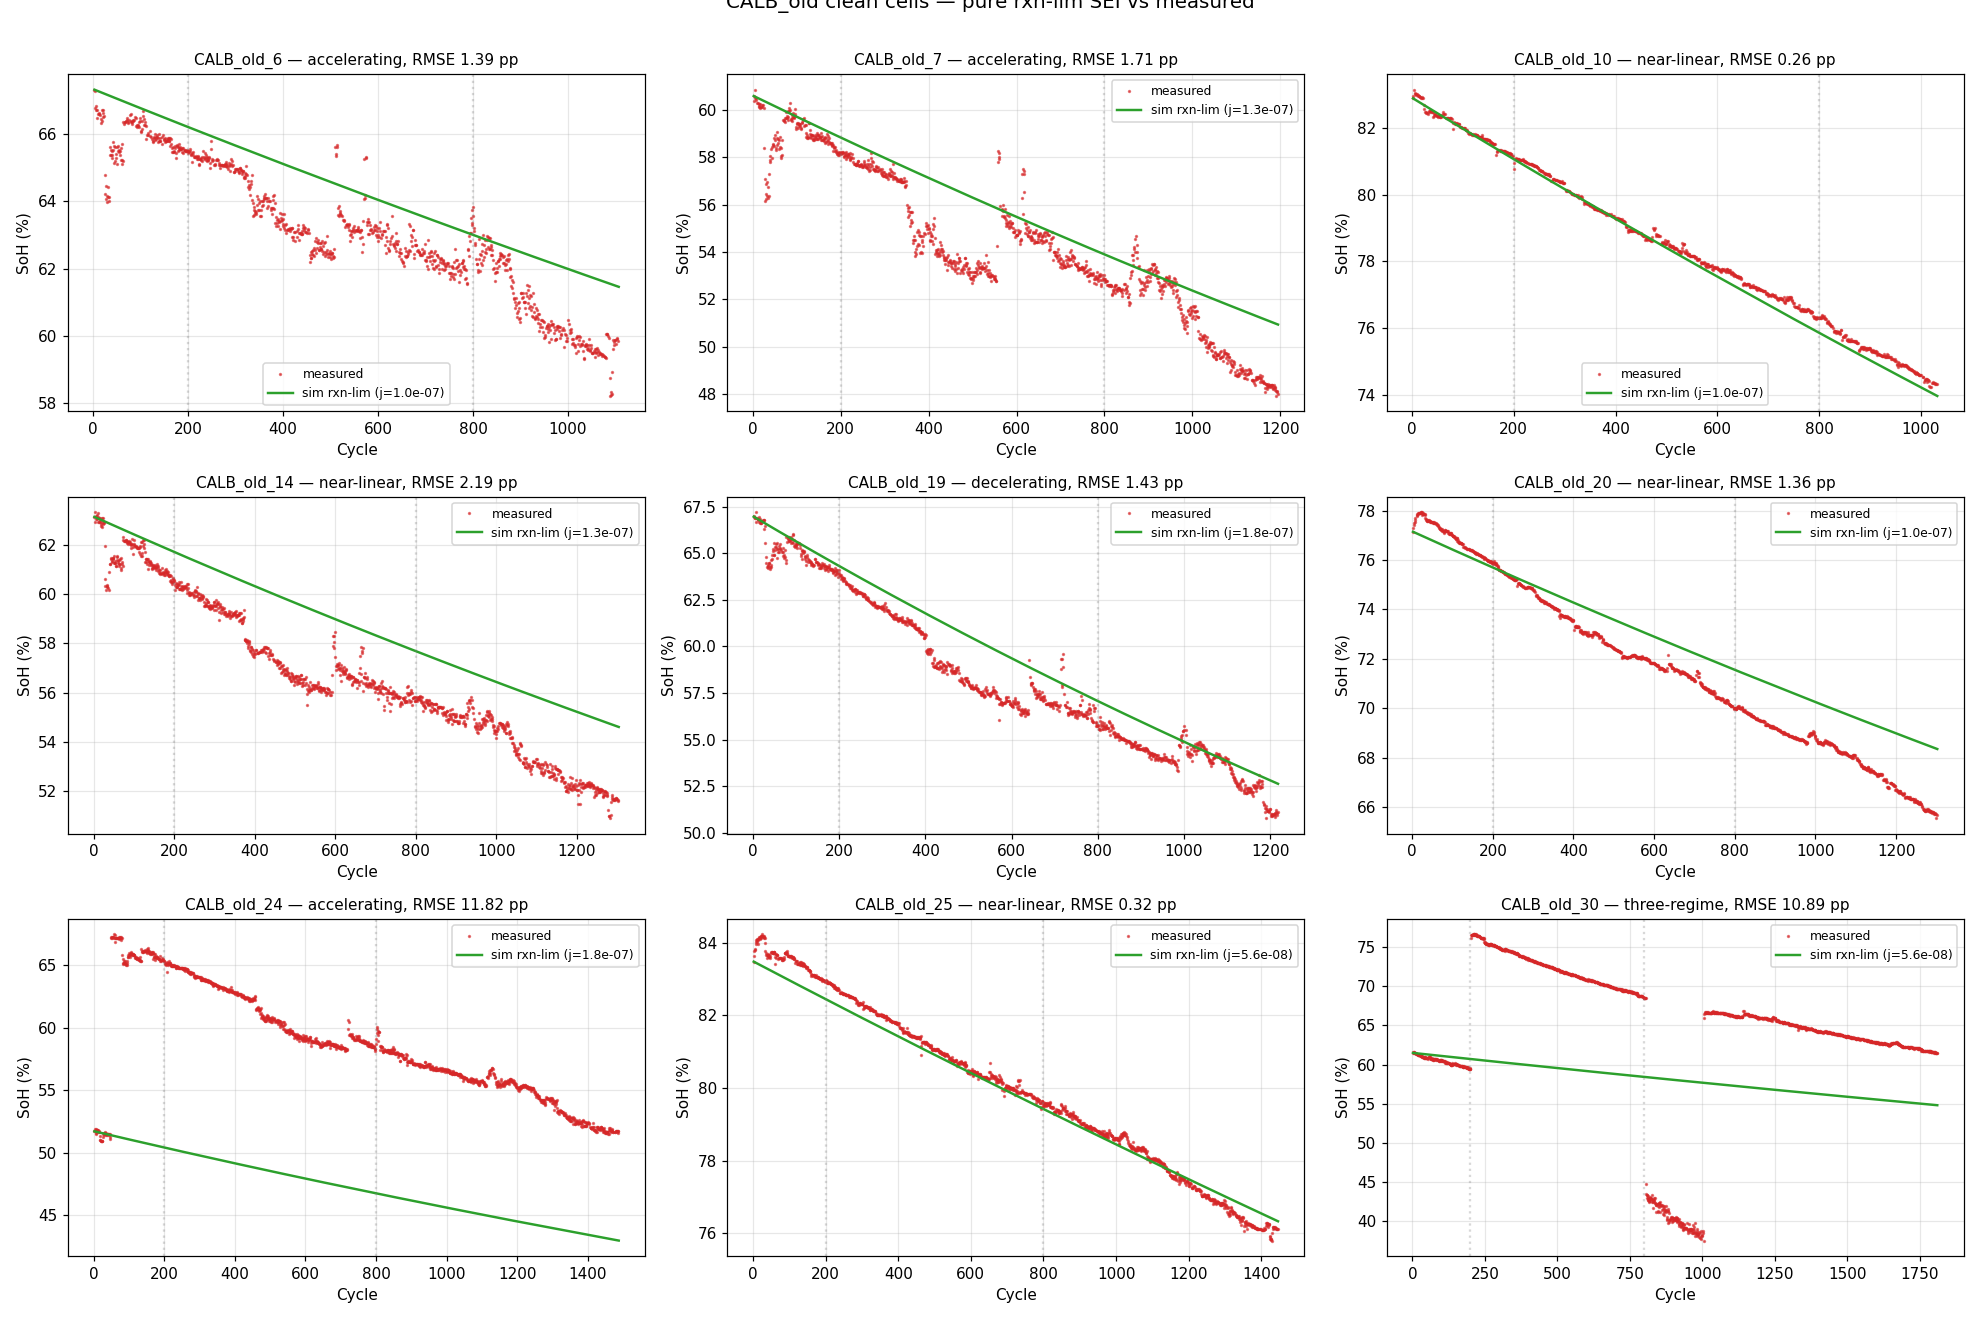

In [4]:
display(Image(filename=str(OUT / "CALB_clean_rxnlim_sweep_grid.png")))

## 4. Cell 24 + cell 30 — why they fail

Both have shapes pure SEI can't reproduce:
- **Cell 24** ("accelerating" but with +7.5 pp/100cy *early slope*): the measured trace appears to *gain* capacity in the first 200 cycles before dropping — almost certainly a measurement / protocol artifact, not real aging. Pure SEI sees this as "no fade then sudden fade" and can't produce that shape. Calibration target slope of -0.83 pp/100cy is the linear average, but the sim follows that slope from cy 1 while measured stays flat then dives.
- **Cell 30** ("three-regime"): same diagnosis as cell 26 in notebook 08 — mid-window acceleration, late-window flattening. Pure SEI is monotonically sublinear; can't reproduce the regime change.

Cells 26 and 30 are the only true three-regime cells in CALB_old; cells 24 and 26 are the only ones with materially non-monotonic early windows. The other 6 clean cells (10, 14, 19, 20, 25, plus 6 and 7) are all well-fit by pure rxn-lim.

## 5. Routing rule for the Voltaris production sweep

Based on the per-cell shape classification (computed from the smoothed measured
trace's early/mid/late window slopes), route each cell to an appropriate model:

| Shape | Action | Cells in this cohort | Expected RMSE |
|---|---|---|---|
| `near-linear`  (`abs(early − mid) < 0.3` AND `abs(mid − late) < 0.3`) | **pure rxn-lim SEI** | 10, 14, 20, 25 | < 2.5 pp |
| `accelerating` (`late < early − 0.3`) | **pure rxn-lim** (works for mild acceleration) | 6, 7 | < 2 pp |
| `decelerating` (`late > early + 0.3`) | **pure rxn-lim** (works for mild deceleration) | 19 | < 2 pp |
| `three-regime` (`mid < early − 0.3` AND `late > mid + 0.5`) | **joint SEI + LAM_neg**, calibrate against full trajectory (not 400-cy window) | 26, 30 | ~5 pp expected; pure SEI fails (8-12 pp) |
| `non-monotonic early` (e.g. cell 24's +7.5 pp/100cy early slope) | **flag for manual inspection** — measurement artifact, not aging | 24 | Pure rxn-lim fails (12+ pp) |

**Two implementation paths:**
1. **Implement the router** as a small function on top of the existing rxn-lim sweep. Detect shape from measured data, dispatch to the right calibration recipe. Production-ready for the cohort sweep that feeds Voltaris Step 3.
2. **Filter out the failure cells** from the cohort and document that they need bespoke calibration. Faster but loses ~22% of the cohort's signal.

In [5]:
# Connection to original Voltaris goal: this is per-cell ground truth feeding Step 3.
# Print the j_SEI distribution for the cells that the production pipeline would route
# to pure rxn-lim (RMSE < 5 pp).
router_pass = df[df.rmse_full_pp < 5].sort_values("j_SEI")
print("Cells that pure rxn-lim handles well (RMSE < 5 pp):")
print(router_pass[["cell","shape","j_SEI","rmse_full_pp"]].to_string(index=False))
print(f"\nj_SEI median: {router_pass.j_SEI.median():.3e}")
print(f"j_SEI range:  {router_pass.j_SEI.min():.2e} — {router_pass.j_SEI.max():.2e}")
print(f"\nCells flagged for non-pure-SEI handling:")
print(df[df.rmse_full_pp >= 5][["cell","shape","rmse_full_pp"]].to_string(index=False))

Cells that pure rxn-lim handles well (RMSE < 5 pp):
       cell        shape        j_SEI  rmse_full_pp
CALB_old_25  near-linear 5.623413e-08      0.321039
 CALB_old_6 accelerating 1.000000e-07      1.388218
CALB_old_20  near-linear 1.000000e-07      1.363071
CALB_old_10  near-linear 1.000000e-07      0.256686
CALB_old_14  near-linear 1.333521e-07      2.193298
 CALB_old_7 accelerating 1.333521e-07      1.711361
CALB_old_19 decelerating 1.778279e-07      1.430796

j_SEI median: 1.000e-07
j_SEI range:  5.62e-08 — 1.78e-07

Cells flagged for non-pure-SEI handling:
       cell        shape  rmse_full_pp
CALB_old_24 accelerating     11.819518
CALB_old_30 three-regime     10.889098


## 6. What this means for the project

- **The joint SEI + LAM machinery from notebook 08 is *not* the production default.** Pure reaction-limited SEI handles 78 % of clean CALB_old cells with RMSE < 2.5 pp.
- **The j_SEI distribution across cells is tight** (~5×10⁻⁸ to ~2×10⁻⁷, less than a half-order of magnitude). That's a much more interpretable cohort-level parameter than the wide D_SEI spread we saw for solv-diff.
- **Two failure modes for the production router to handle:**
  1. Three-regime shape (cells 26, 30) — needs joint SEI + LAM with full-trajectory calibration window
  2. Non-monotonic early shape (cell 24) — measurement artifact, not aging — should be flagged for manual review or excluded from cohort statistics
- **Connection to Voltaris**: these calibrated per-cell j_SEI values are the per-cell ground-truth parameters that Step 3 (synthetic-trajectory sweep) consumes. The fact that 7 of 9 cells share a tight j_SEI distribution means the Step-3 sweep can be a low-dimensional sensitivity scan around the median, not a per-cell custom build.